In [78]:
#!pip install pandas matplotlib seaborn scipy numpy
import sys
print(sys.executable)
import matplotlib
print(matplotlib.__file__)
#!pip install pandas matplotlib seaborn scipy numpy


/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/bin/python
/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/lib/python3.11/site-packages/matplotlib/__init__.py


In [79]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [34]:
!python --version

Python 3.11.9


In [80]:
CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

In [81]:
SECCHI_COLS = [
    "Cst_Cnt",
    "Cruise_ID",
    "Cruz_Sta",
    "Cast_ID",
    "Sta_ID",
    "Distance",
    "Date",
    "Time",
    "Lat_Dec",
    "Lon_Dec",
    "Ac_Line",
    "Bottom_D",
    "IntChl",
    "IntC14",
    "TimeZone",
    "Visibility",
    "Secchi",
]

DOWNCAST_COLS = [
    "ORD_OCC",
    "CAST_ID",
    "DATE_TIME_UTC",
    "DATE_TIME_PST",
    "LAT_DEC",
    "LON_DEC",
    "STA_ID",
    "STA",
    "LINE",
    "DEPTH",
    "PRESSURE",
    "ESTCHL_CRUISECORR",
    "ESTCHL_STACORR",
    "BAT",
    "XMISS",
    "SPAR",
    "PAR",
    "CHL_A",
    "PHAEO",
    "CAST_COUNT"
]

In [82]:
def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)

    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)

    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(
        csv_path,
        usecols=usecols,
        low_memory=False
    )

    # Normalize object columns so Parquet doesn't choke
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")

    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)

    return df

data_downcast = load_or_cache(
    "../Data/downcast_all.csv",
    CACHE_DIR / "downcast.parquet",
    usecols=DOWNCAST_COLS
)

data_secchi = load_or_cache(
    "../Data/Secchi.csv",
    CACHE_DIR / "secchi.parquet",
    usecols=SECCHI_COLS
)


Loading cached: ../Data/Parquet/downcast.parquet
Loading cached: ../Data/Parquet/secchi.parquet


In [83]:
# Convert PAR to numeric if it's a string
if data_downcast["PAR"].dtype == "string":
    data_downcast["PAR"] = pd.to_numeric(data_downcast["PAR"], errors='coerce')

# Convert CAST_COUNT to numeric if it's a string
if data_downcast["CAST_COUNT"].dtype == "string":
    data_downcast["CAST_COUNT"] = pd.to_numeric(data_downcast["CAST_COUNT"], errors='coerce')

# Convert DEPTH to numeric if it's a string
if data_downcast["DEPTH"].dtype == "string":
    data_downcast["DEPTH"] = pd.to_numeric(data_downcast["DEPTH"], errors='coerce')

# Convert STA to numeric if it's a string
if data_downcast["STA"].dtype == "string":
    data_downcast["STA"] = pd.to_numeric(data_downcast["STA"], errors='coerce')

# Convert Secchi to numeric if it's a string
if data_secchi["Secchi"].dtype == "string":
    data_secchi["Secchi"] = pd.to_numeric(data_secchi["Secchi"], errors='coerce')

# Convert Cst_Cnt to numeric if it's a string (for consistency)
if data_secchi["Cst_Cnt"].dtype == "string":
    data_secchi["Cst_Cnt"] = pd.to_numeric(data_secchi["Cst_Cnt"], errors='coerce')

# Convert XMISS into numeric (in case it's a string)
if data_downcast["XMISS"].dtype == "string":
    data_downcast["XMISS"] = pd.to_numeric(data_downcast["XMISS"], errors='coerce')

# Convert BAT into numeric (in case it's a string)
if data_downcast["BAT"].dtype == "string":
    data_downcast["BAT"] = pd.to_numeric(data_downcast["BAT"], errors='coerce')

# Convert pressure into numeric (in case it's a string)
if data_downcast["PRESSURE"].dtype == "string":
    data_downcast["PRESSURE"] = pd.to_numeric(data_downcast["PRESSURE"], errors='coerce')

# Convert ESTCHL_CRUISECORR into numeric (in case it's a string)
if data_downcast["ESTCHL_CRUISECORR"].dtype == "string":
    data_downcast["ESTCHL_CRUISECORR"] = pd.to_numeric(data_downcast["ESTCHL_CRUISECORR"], errors='coerce')

# convert ESTCHL_STACORR into numeric (in case it's a string)
if data_downcast["ESTCHL_STACORR"].dtype == "string":
    data_downcast["ESTCHL_STACORR"] = pd.to_numeric(data_downcast["ESTCHL_STACORR"], errors='coerce')

# Convert CHL_A into numeric (in case it's a string)
if data_downcast["CHL_A"].dtype == "string":
    data_downcast["CHL_A"] = pd.to_numeric(data_downcast["CHL_A"], errors='coerce')

# Convert PHAEO into numeric (in case it's a string)
if data_downcast["PHAEO"].dtype == "string":
    data_downcast["PHAEO"] = pd.to_numeric(data_downcast["PHAEO"], errors='coerce')

# Convert SPAR into numeric (in case it's a string)
if data_downcast["SPAR"].dtype == "string":
    data_downcast["SPAR"] = pd.to_numeric(data_downcast["SPAR"], errors='coerce')

# Convert distance into numeric (in case it's a string)
if data_secchi["Distance"].dtype == "string":
    data_secchi["Distance"] = pd.to_numeric(data_secchi["Distance"], errors='coerce')


In [39]:
# Checking number of rows and columns
print("Downcast:", data_downcast.shape)
print("Secchi:", data_secchi.shape)

Downcast: (3800269, 20)
Secchi: (35644, 17)


In [40]:
# Merging the data

## Filtering the data so we only include secchi >0 and par >0 and not null
secchi_filtered = data_secchi[data_secchi["Secchi"].notna() & (data_secchi["Secchi"] > 0)]
downcast_filtered = data_downcast[data_downcast["PAR"].notna() & (data_downcast["PAR"] > 0)]

print(f"\nAfter filtering:")
print(f"Secchi filtered: {secchi_filtered.shape}")
print(f"Downcast filtered: {downcast_filtered.shape}")

# Keeping only necessary Cast count / ID 
valid_casts = set(secchi_filtered["Cst_Cnt"]) & set(downcast_filtered["CAST_COUNT"])
print(f"Number of overlapping casts: {len(valid_casts)}")

secchi_filtered = secchi_filtered[secchi_filtered["Cst_Cnt"].isin(valid_casts)]
downcast_filtered = downcast_filtered[downcast_filtered["CAST_COUNT"].isin(valid_casts)]

# Add sort helper column - downcast rows = 0, secchi rows = 1 (so secchi comes last)
downcast_filtered = downcast_filtered.copy()
downcast_filtered["_sort_order"] = 0

# Creating extra rows for each cast count for secchi
secchi_extra_rows = secchi_filtered.copy()
secchi_extra_rows = secchi_extra_rows.rename(columns={"Cst_Cnt": "CAST_COUNT"})
secchi_extra_rows["_sort_order"] = 1  # Secchi rows come last

# Fill all downcast rows with NA for the extra secchi rows
downcast_cols = data_downcast.columns.tolist()
for col in downcast_cols:
    if col != "CAST_COUNT":  # keep CAST_COUNT for merge
        secchi_extra_rows[col] = pd.NA

# Reorder columns so downcast columns come first
secchi_extra_rows = secchi_extra_rows[downcast_cols + ["_sort_order"] + [c for c in secchi_extra_rows.columns if c not in downcast_cols and c != "_sort_order"]]

# Merge
merged_df = pd.concat([downcast_filtered, secchi_extra_rows], ignore_index=True, sort=False)

# Sort by CAST_COUNT first, then by _sort_order (so secchi rows come at the end of each cast)
merged_df = merged_df.sort_values(by=["CAST_COUNT", "_sort_order"], ignore_index=True)

# Remove the helper column
merged_df = merged_df.drop(columns=["_sort_order"])

# Convert DEPTH and STA in merged_df to numeric (in case it's still a string from Secchi rows)
if merged_df["DEPTH"].dtype == "string" or merged_df["DEPTH"].dtype == "object":
    merged_df["DEPTH"] = pd.to_numeric(merged_df["DEPTH"], errors='coerce')

if merged_df["STA"].dtype == "string" or merged_df["STA"].dtype == "object":
    merged_df["STA"] = pd.to_numeric(merged_df["STA"], errors='coerce')


After filtering:
Secchi filtered: (5689, 17)
Downcast filtered: (3359981, 20)
Number of overlapping casts: 2774


# When threshold is 4.7% of light
This is also using only depth 2, if 2 is unavailable, it is skipping. Other idea is to use the shallowest depth and adjust the correlation

In [69]:
# ===== PHOTIC ZONE CALCULATION =====
print("\nCalculating photic zones...")

# Initialize PHOTIC_ZONE column as False for all rows
merged_df['PHOTIC_ZONE'] = False

# Counters for statistics
used_depth_2 = 0
used_shallowest = 0

# Process each cast
for cast_id in valid_casts:
    # Get all rows for this cast
    cast_mask = merged_df['CAST_COUNT'] == cast_id
    cast_data = merged_df[cast_mask].copy()
    
    # Filter to rows with valid PAR and DEPTH (excludes Secchi row)
    par_mask = cast_data['PAR'].notna() & cast_data['DEPTH'].notna() & (cast_data['DEPTH'] > 0)
    par_data = cast_data[par_mask].copy()
    
    if len(par_data) == 0:
        continue
    
    # Sort by depth
    par_data = par_data.sort_values('DEPTH')
    
    # Try to find depth = 2, otherwise use shallowest
    # Only use depth = 2 as baseline
    depth_2_rows = par_data[par_data['DEPTH'] == 2]

    if len(depth_2_rows) > 0:
        # Use depth 2 as baseline
        baseline_par = depth_2_rows['PAR'].iloc[0]
        used_depth_2 += 1
        
        # Calculate 4.7% threshold
        threshold_par = baseline_par * 0.047
        
        # Find first depth where PAR <= threshold
        below_threshold = par_data[par_data['PAR'] <= threshold_par]
        
        if len(below_threshold) > 0:
            # Get the index of the first row that crosses the threshold
            photic_idx = below_threshold.index[0]
            # Mark it as True in the main dataframe
            merged_df.loc[photic_idx, 'PHOTIC_ZONE'] = True
    else:
        # Skip this cast - no depth 2 available
        used_shallowest += 1

MERGED_PATH = Path("../Data/merged_dataset_organized_47photic.csv")
merged_df.to_csv(MERGED_PATH, index=False)
print(f"Merged dataset saved to {MERGED_PATH}, shape: {merged_df.shape}")

# Print statistics
photic_count = merged_df['PHOTIC_ZONE'].sum()
print(f"\nPhotic zone statistics:")
print(f"Number of photic zone depths marked: {photic_count}")
print(f"Number of unique casts: {len(valid_casts)}")
print(f"Casts using depth=2 as baseline: {used_depth_2}")
print(f"Casts using shallowest depth as baseline: {used_shallowest}")


Calculating photic zones...
Merged dataset saved to ../Data/merged_dataset_organized_47photic.csv, shape: (1255966, 37)

Photic zone statistics:
Number of photic zone depths marked: 1971
Number of unique casts: 2774
Casts using depth=2 as baseline: 2285
Casts using shallowest depth as baseline: 489


In [70]:
# ===== CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI BY SHORE PROXIMITY =====
print("\n" + "="*60)
print("CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI")
print("BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)")
print("="*60)

# Get photic zone data
photic_zone_data = merged_df[merged_df['PHOTIC_ZONE'] == True].copy()

# For each cast, match photic depth with Secchi value
correlation_data = []

for cast_id in valid_casts:
    # Get photic zone row for this cast
    photic_row = photic_zone_data[photic_zone_data['CAST_COUNT'] == cast_id]
    if len(photic_row) == 0:
        continue
    
    # Get Secchi value for this cast
    cast_rows = merged_df[merged_df['CAST_COUNT'] == cast_id]
    secchi_row = cast_rows[cast_rows['Secchi'].notna()]
    
    if len(secchi_row) == 0:
        continue
    
    photic_depth = photic_row['DEPTH'].iloc[0]
    secchi_value = secchi_row['Secchi'].iloc[0]
    sta_value = photic_row['STA'].iloc[0]
    
    # Determine shore proximity
    if pd.notna(sta_value):
        shore_proximity = 'Near Shore' if sta_value <= 60 else 'Offshore'
    else:
        shore_proximity = 'Unknown'
    
    correlation_data.append({
        'CAST_COUNT': cast_id,
        'PHOTIC_DEPTH': photic_depth,
        'SECCHI': secchi_value,
        'STA': sta_value,
        'SHORE_PROXIMITY': shore_proximity
    })

corr_df = pd.DataFrame(correlation_data)
corr_df["PHOTIC_DEPTH"] = pd.to_numeric(corr_df["PHOTIC_DEPTH"], errors="coerce")
corr_df["SECCHI"] = pd.to_numeric(corr_df["SECCHI"], errors="coerce")

# Save correlation data
CORR_PATH = Path("../Data/photic_depth_secchi_correlation_by_shore.csv")
corr_df.to_csv(CORR_PATH, index=False)
print(f"\nCorrelation data saved to {CORR_PATH}")
print(f"Total matched pairs: {len(corr_df)}")

# Split by shore proximity
near_shore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Near Shore']
offshore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Offshore']

print(f"\nNear Shore (STA <= 60): {len(near_shore_df)} observations")
print(f"Offshore (STA > 60): {len(offshore_df)} observations")

# Calculate correlations for OVERALL data
if len(corr_df) > 0:
    print("\n" + "="*60)
    print("OVERALL CORRELATIONS (All Data)")
    print("="*60)
    
    pearson_overall = stats.pearsonr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    spearman_overall = stats.spearmanr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_overall[0]:.4f}, p-value = {pearson_overall[1]:.4e}")
    print(f"  Spearman ρ = {spearman_overall[0]:.4f}, p-value = {spearman_overall[1]:.4e}")

# Calculate correlations for NEAR SHORE
if len(near_shore_df) > 1:
    print("\n" + "="*60)
    print("NEAR SHORE CORRELATIONS (STA <= 60)")
    print("="*60)
    
    pearson_near = stats.pearsonr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    spearman_near = stats.spearmanr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_near[0]:.4f}, p-value = {pearson_near[1]:.4e}")
    print(f"  Spearman ρ = {spearman_near[0]:.4f}, p-value = {spearman_near[1]:.4e}")
else:
    print("\nNot enough Near Shore data for correlation")
    pearson_near = (0, 1)  # dummy values for plotting

# Calculate correlations for OFFSHORE
if len(offshore_df) > 1:
    print("\n" + "="*60)
    print("OFFSHORE CORRELATIONS (STA > 60)")
    print("="*60)
    
    pearson_off = stats.pearsonr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    spearman_off = stats.spearmanr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_off[0]:.4f}, p-value = {pearson_off[1]:.4e}")
    print(f"  Spearman ρ = {spearman_off[0]:.4f}, p-value = {spearman_off[1]:.4e}")
else:
    print("\nNot enough Offshore data for correlation")
    pearson_off = (0, 1)  # dummy values for plotting


CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI
BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)

Correlation data saved to ../Data/photic_depth_secchi_correlation_by_shore.csv
Total matched pairs: 1971

Near Shore (STA <= 60): 1102 observations
Offshore (STA > 60): 869 observations

OVERALL CORRELATIONS (All Data)

Photic Depth vs Secchi:
  Pearson r = 0.7283, p-value = 0.0000e+00
  Spearman ρ = 0.7583, p-value = 0.0000e+00

NEAR SHORE CORRELATIONS (STA <= 60)

Photic Depth vs Secchi:
  Pearson r = 0.6617, p-value = 8.9692e-140
  Spearman ρ = 0.6683, p-value = 1.6806e-143

OFFSHORE CORRELATIONS (STA > 60)

Photic Depth vs Secchi:
  Pearson r = 0.5755, p-value = 8.7990e-78
  Spearman ρ = 0.6265, p-value = 6.5977e-96



Creating visualizations...
Visualization saved to ../results/47photic_depth_secchi_shore_comparison.png


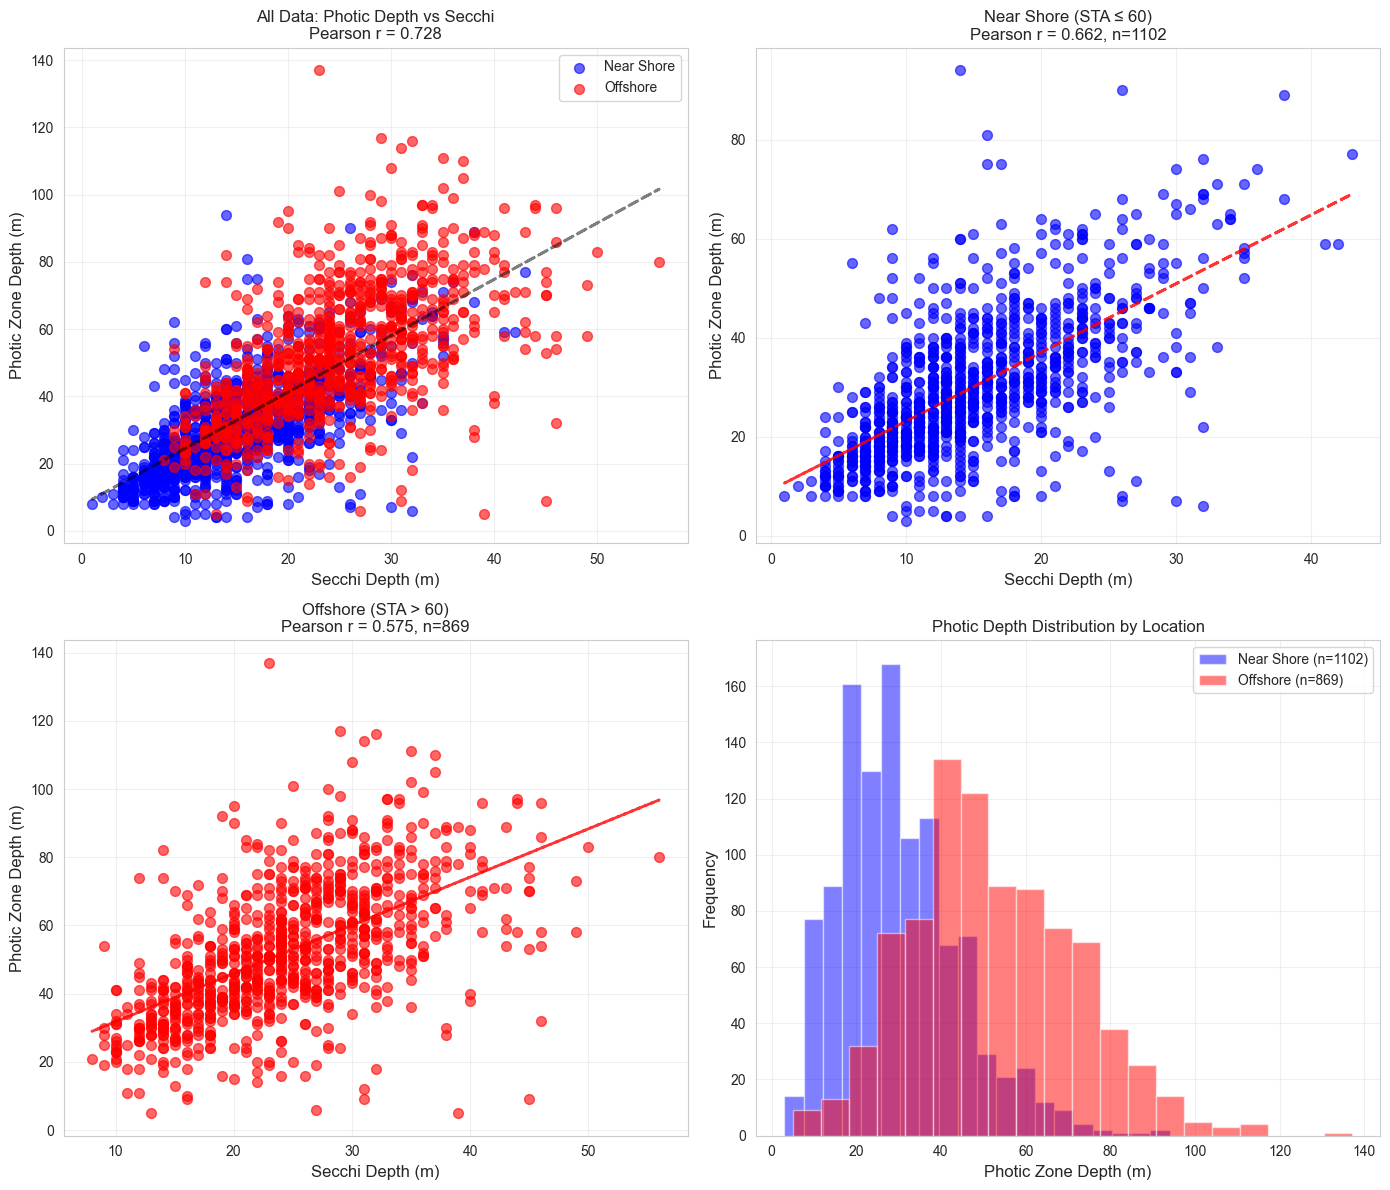

In [71]:
# ===== VISUALIZATIONS =====
print("\nCreating visualizations...")

# Set up the plotting style
sns.set_style("whitegrid")

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Overall scatter plot with color by shore proximity
if len(corr_df) > 0:
    for proximity, color in [('Near Shore', 'blue'), ('Offshore', 'red')]:
        subset = corr_df[corr_df['SHORE_PROXIMITY'] == proximity]
        if len(subset) > 0:
            axes[0, 0].scatter(subset['SECCHI'], subset['PHOTIC_DEPTH'], 
                             alpha=0.6, s=50, c=color, label=proximity)
    
    axes[0, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 0].set_title(f'All Data: Photic Depth vs Secchi\nPearson r = {pearson_overall[0]:.3f}', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add overall regression line
    z_all = np.polyfit(corr_df['SECCHI'], corr_df['PHOTIC_DEPTH'], 1)
    p_all = np.poly1d(z_all)
    axes[0, 0].plot(corr_df['SECCHI'], p_all(corr_df['SECCHI']), 
                   "k--", alpha=0.5, linewidth=2, label='Overall fit')

# Plot 2: Near Shore only
if len(near_shore_df) > 1:
    axes[0, 1].scatter(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='blue')
    axes[0, 1].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 1].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 1].set_title(f'Near Shore (STA ≤ 60)\nPearson r = {pearson_near[0]:.3f}, n={len(near_shore_df)}', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Add regression line
    z_near = np.polyfit(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 1)
    p_near = np.poly1d(z_near)
    axes[0, 1].plot(near_shore_df['SECCHI'], p_near(near_shore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 3: Offshore only
if len(offshore_df) > 1:
    axes[1, 0].scatter(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='red')
    axes[1, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[1, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[1, 0].set_title(f'Offshore (STA > 60)\nPearson r = {pearson_off[0]:.3f}, n={len(offshore_df)}', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add regression line
    z_off = np.polyfit(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 1)
    p_off = np.poly1d(z_off)
    axes[1, 0].plot(offshore_df['SECCHI'], p_off(offshore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 4: Distribution comparison
axes[1, 1].hist(near_shore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Near Shore (n={len(near_shore_df)})', color='blue')
axes[1, 1].hist(offshore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Offshore (n={len(offshore_df)})', color='red')
axes[1, 1].set_xlabel('Photic Zone Depth (m)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Photic Depth Distribution by Location', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

PLOT_PATH = Path("../results/47photic_depth_secchi_shore_comparison.png")
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
print(f"Visualization saved to {PLOT_PATH}")

# Running Random Forest Model

In [ ]:
#!pip install scikit-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 26.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [72]:
# Random Forest Model

print("\n" + "="*60)
print("RANDOM FOREST MODEL: Predicting Photic Depth from Secchi")
print("="*60)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Get photic zone data with all downcast columns
photic_zone_data = merged_df[merged_df['PHOTIC_ZONE'] == True].copy()

# For each cast, get the downcast variables at photic depth row and match with Secchi
model_data_list = []

for cast_id in valid_casts:
    # Get photic zone row for this cast (this has all downcast variables)
    photic_row = photic_zone_data[photic_zone_data['CAST_COUNT'] == cast_id]
    
    if len(photic_row) == 0:
        continue
    
    # Get Secchi value for this cast
    cast_rows = merged_df[merged_df['CAST_COUNT'] == cast_id]
    secchi_row = cast_rows[cast_rows['Secchi'].notna()]
    
    if len(secchi_row) == 0:
        continue
    
    # Get all downcast variables from the photic depth row
    row_data = photic_row.iloc[0].to_dict()
    row_data['SECCHI'] = secchi_row['Secchi'].iloc[0]
    
    model_data_list.append(row_data)

# Create DataFrame
model_df = pd.DataFrame(model_data_list)

print(f"\nData for modeling: {len(model_df)} observations")
print(f"Columns available: {model_df.columns.tolist()}")



RANDOM FOREST MODEL: Predicting Photic Depth from Secchi

Data for modeling: 1971 observations
Columns available: ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'PHOTIC_ZONE', 'SECCHI']


In [73]:
# Select feature columns (all downcast columns except the target and identifiers)
# Exclude: CAST_COUNT, PHOTIC_ZONE, and any Secchi-specific columns
from sklearn.model_selection import train_test_split


exclude_cols = ['CAST_COUNT', 'PHOTIC_ZONE', 'SECCHI', 'CAST_ID', 'ORD_OCC', 
                'DATE_TIME_UTC', 'DATE_TIME_PST', 'STA_ID', 'TimeZone',
                'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID', 'Distance', 
                'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 
                'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility',]
# So now the variables we have are: 'LAT_DEC', 'LON_DEC', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 
# 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 

for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Get all numeric columns that are not excluded
feature_cols = [col for col in model_df.columns 
                if col not in exclude_cols]
print(f"Feature columns: {feature_cols}")

# View model_df with only feature columns and target
#print("\nSample of model data:")
#print(model_df[feature_cols + ['SECCHI']].head())

model_df_clean = model_df[feature_cols + ['SECCHI']].dropna(subset=['SECCHI'])

print("\nSample of model data:")
print(model_df_clean[feature_cols + ['SECCHI']].head())

print(f"Data after removing rows with missing SECCHI: {len(model_df_clean)} observations")

# Split by shore proximity
near_shore_df = model_df_clean[model_df_clean['STA'] <= 60]
offshore_df = model_df_clean[model_df_clean['STA'] > 60]

print(f"\nNear Shore (STA <= 60): {len(near_shore_df)} observations")
print(f"Offshore (STA > 60): {len(offshore_df)} observations")

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

# Function to train and evaluate Random Forest
def train_random_forest(X, y, feature_names, model_name, n_estimators=100, test_size=0.2):
    """
    Train Random Forest with train/test split and 5-fold cross-validation
    """
    print(f"\n{'='*60}")
    print(f"Training Random Forest: {model_name}")
    print(f"{'='*60}")

    # Split data into train and test (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\nData split:")
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set:     {len(X_test)} samples")
    print(f"  Number of features: {X.shape[1]}")

    # Initialize Random Forest
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1,  # Use all CPU cores
        max_depth=10,  # Prevent overfitting
        min_samples_split=5
    )

    # 5-fold cross-validation ON TRAINING DATA ONLY
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Cross-validation scores
    cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)

    print(f"\n5-Fold Cross-Validation RMSE (on training data):")
    print(f"  Mean: {cv_rmse.mean():.4f}")
    print(f"  Std:  {cv_rmse.std():.4f}")

    # R² scores
    cv_r2 = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='r2')
    print(f"\n5-Fold Cross-Validation R² (on training data):")
    print(f"  Mean: {cv_r2.mean():.4f}")
    print(f"  Std:  {cv_r2.std():.4f}")
    
    # Train final model on all training data
    rf.fit(X_train, y_train)

    # Predictions on training data
    y_train_pred = rf.predict(X_train)

    # Training metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    print(f"\nTraining Set Performance:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")
    print(f"  R²:   {train_r2:.4f}")

    # Predictions on test data
    y_test_pred = rf.predict(X_test)

    # Test metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"\nTest Set Performance:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")
    print(f"  R²:   {test_r2:.4f}")

    # Feature importance
    print(f"\nTop 10 Most Important Features:")
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(feature_importance.head(10).to_string(index=False))

    # Save feature importance
    importance_path = models_dir / f"{model_name}_feature_importance.csv"
    feature_importance.to_csv(importance_path, index=False)
    print(f"\nFeature importance saved to: {importance_path}")
    
    # Save model
    model_path = models_dir / f"{model_name}.joblib"
    joblib.dump(rf, model_path)
    print(f"Model saved to: {model_path}")

    return {
        'model': rf,
        'cv_rmse': cv_rmse,
        'cv_r2': cv_r2,
        'X_train': X_train,
        'y_train': y_train,
        'y_train_pred': y_train_pred,
        'X_test': X_test,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'feature_importance': feature_importance
    }

# Train models
results = {}

# Overall model
if len(model_df_clean) > 20:
    X_overall = model_df_clean[feature_cols].values
    y_overall = model_df_clean['SECCHI'].values
    
    results['overall'] = train_random_forest(
        X_overall, y_overall, feature_cols, "rf_overall_all_features"
    )

# Near Shore model
if len(near_shore_df) > 20:
    X_near = near_shore_df[feature_cols].values
    y_near = near_shore_df['SECCHI'].values
    
    results['near_shore'] = train_random_forest(
        X_near, y_near, feature_cols, "rf_near_shore_all_features"
    )

# Offshore model
if len(offshore_df) > 20:
    X_off = offshore_df[feature_cols].values
    y_off = offshore_df['SECCHI'].values
    
    results['offshore'] = train_random_forest(
        X_off, y_off, feature_cols, "rf_offshore_all_features"
    )


Feature columns: ['LAT_DEC', 'LON_DEC', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO']

Sample of model data:
   LAT_DEC  LON_DEC  LINE    STA  DEPTH  PRESSURE  ESTCHL_CRUISECORR  \
0    31.99  -122.40  86.7   90.0   41.0     41.29               0.38   
1    33.24  -118.25  90.0   35.0   28.0     28.20               2.72   
2    33.18  -118.39  90.0   37.0   27.0     27.19               2.13   
3    32.41  -119.96  90.0   60.0   23.0     23.16               2.78   
4    31.07  -122.65  90.0  100.0   38.0     38.26               2.48   

   ESTCHL_STACORR   BAT  XMISS    SPAR   PAR  CHL_A  PHAEO  SECCHI  
0            0.33  0.64  85.01   422.1  0.76    NaN    NaN    19.0  
1            1.56  0.86  80.56  2252.5  5.21    NaN    NaN    13.0  
2            0.84  0.80  81.69  1529.9  2.86    NaN    NaN    15.0  
3            1.38  0.97  78.42  2203.3  3.62    NaN    NaN     8.0  
4            1.01  0.75  82.85  202


Creating model prediction visualizations...


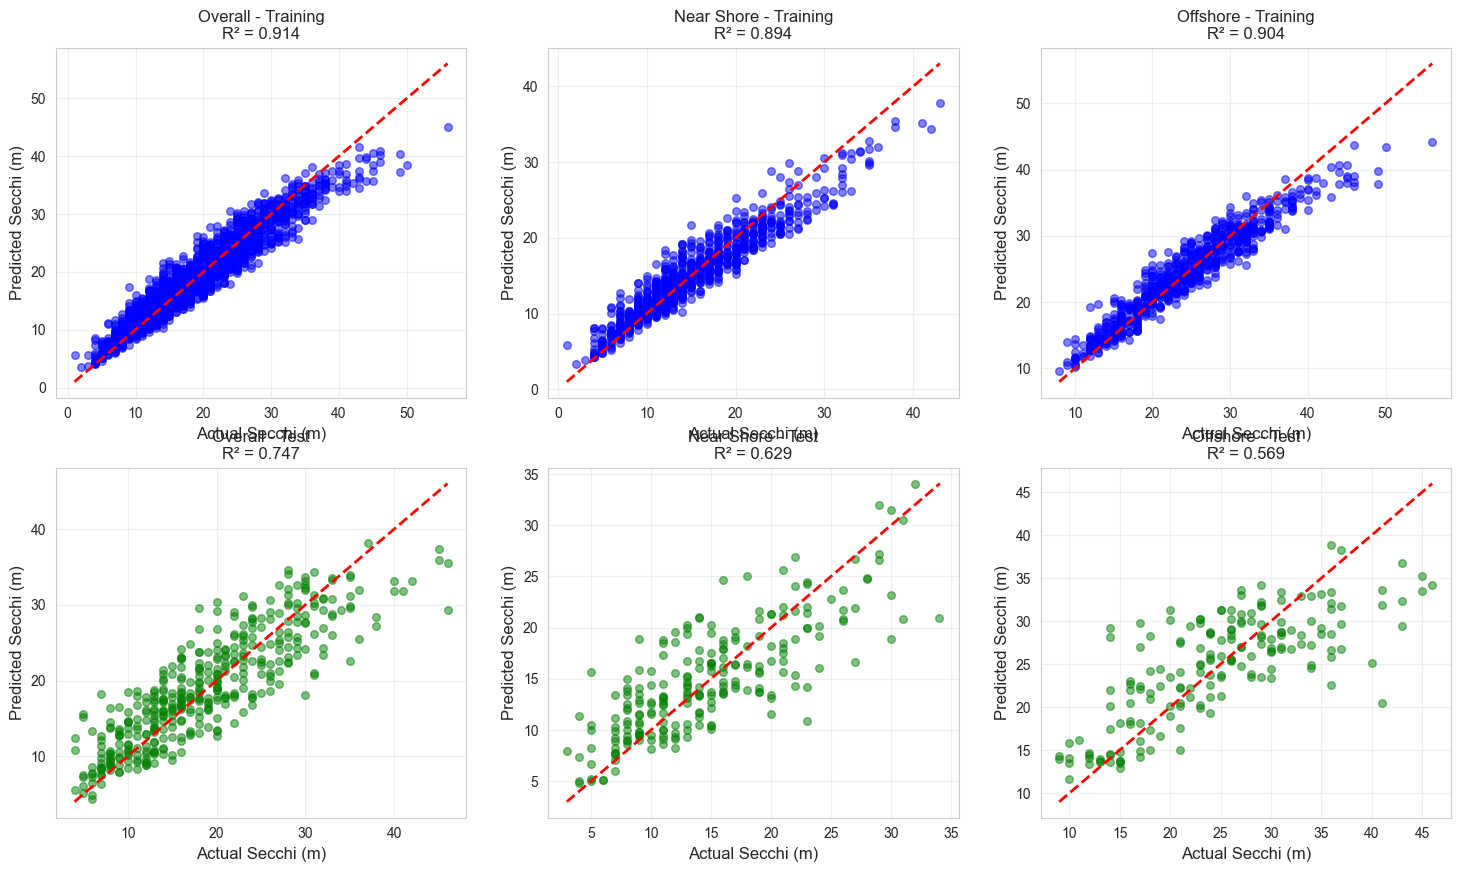

In [74]:
# ===== VISUALIZE MODEL PREDICTIONS =====
print("\nCreating model prediction visualizations...")

fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))

plot_idx = 0
for name, res in results.items():
    # Training data plot (Actual vs Predicted)
    axes2[0, plot_idx].scatter(res['y_train'], res['y_train_pred'], alpha=0.5, s=30, 
                               color='blue')
    # Add diagonal line (perfect prediction)
    min_val = min(res['y_train'].min(), res['y_train_pred'].min())
    max_val = max(res['y_train'].max(), res['y_train_pred'].max())
    axes2[0, plot_idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes2[0, plot_idx].set_xlabel('Actual Secchi (m)', fontsize=12)
    axes2[0, plot_idx].set_ylabel('Predicted Secchi (m)', fontsize=12)
    axes2[0, plot_idx].set_title(f'{name.replace("_", " ").title()} - Training\nR² = {res["train_r2"]:.3f}', 
                                 fontsize=12)
    axes2[0, plot_idx].grid(True, alpha=0.3)

    # Test data plot (Actual vs Predicted)
    axes2[1, plot_idx].scatter(res['y_test'], res['y_test_pred'], alpha=0.5, s=30, 
                               color='green')
    # Add diagonal line (perfect prediction)
    min_val = min(res['y_test'].min(), res['y_test_pred'].min())
    max_val = max(res['y_test'].max(), res['y_test_pred'].max())
    axes2[1, plot_idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes2[1, plot_idx].set_xlabel('Actual Secchi (m)', fontsize=12)
    axes2[1, plot_idx].set_ylabel('Predicted Secchi (m)', fontsize=12)
    axes2[1, plot_idx].set_title(f'{name.replace("_", " ").title()} - Test\nR² = {res["test_r2"]:.3f}', 
                                 fontsize=12)
    axes2[1, plot_idx].grid(True, alpha=0.3)
    
    plot_idx += 1


plt.show()

Feature importance plot saved to: feature_importance.png


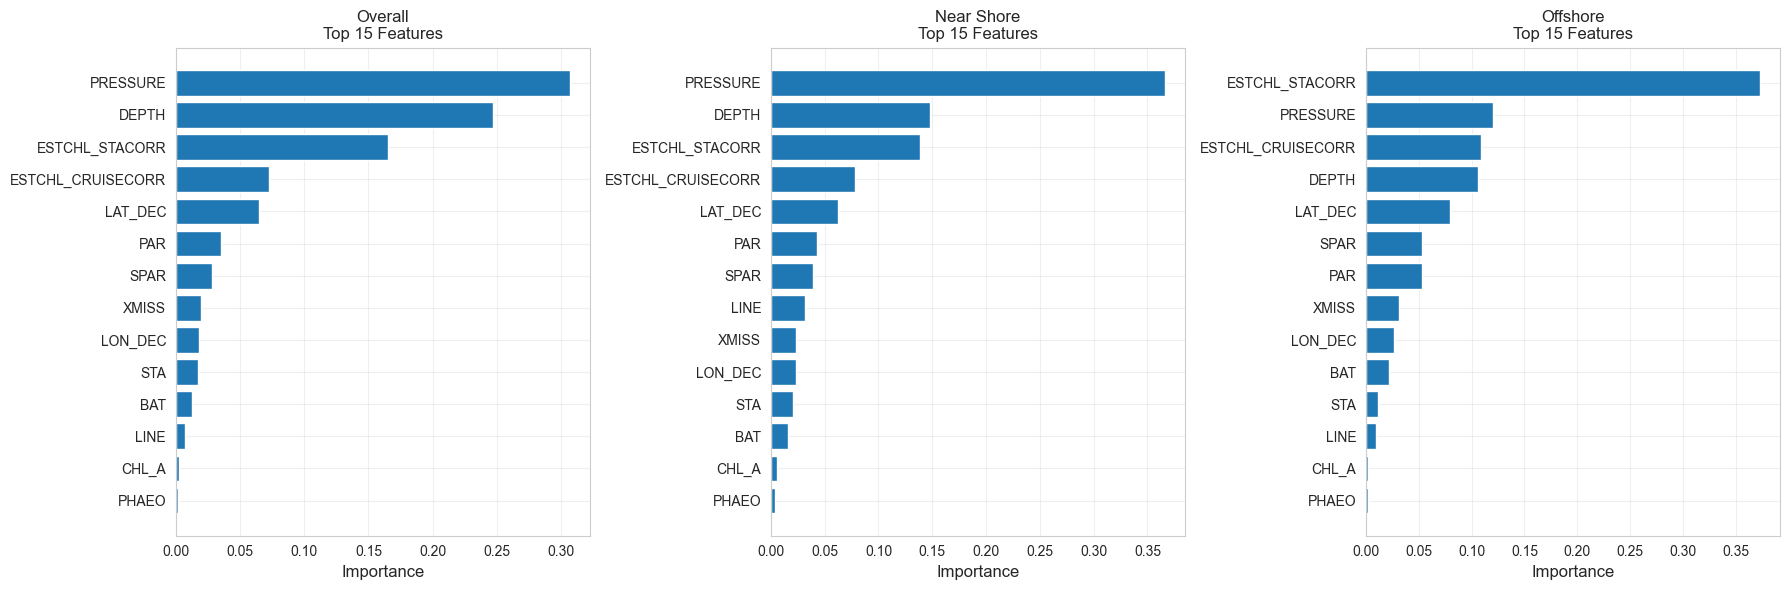

In [75]:
# ===== FEATURE IMPORTANCE VISUALIZATION =====
if len(results) > 0:
    fig3, axes3 = plt.subplots(1, len(results), figsize=(6*len(results), 6))
    if len(results) == 1:
        axes3 = [axes3]
    
    for idx, (name, res) in enumerate(results.items()):
        top_features = res['feature_importance'].head(15)
        axes3[idx].barh(top_features['feature'], top_features['importance'])
        axes3[idx].set_xlabel('Importance', fontsize=12)
        axes3[idx].set_title(f'{name.replace("_", " ").title()}\nTop 15 Features', fontsize=12)
        axes3[idx].invert_yaxis()
        axes3[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    IMPORTANCE_PLOT_PATH = Path("feature_importance.png")
    plt.savefig(IMPORTANCE_PLOT_PATH, dpi=300, bbox_inches='tight')
    print(f"Feature importance plot saved to: {IMPORTANCE_PLOT_PATH}")
    
    plt.show()

In [76]:
# ===== SUMMARY =====
print("\n" + "="*60)
print("RANDOM FOREST SUMMARY")
print("="*60)

for name, res in results.items():
    print(f"\n{name.upper()}:")
    print(f"  Cross-validation R² (train): {res['cv_r2'].mean():.4f} ± {res['cv_r2'].std():.4f}")
    print(f"  Training R²:                  {res['train_r2']:.4f}")
    print(f"  Test R²:                      {res['test_r2']:.4f}")
    print(f"  Training RMSE:                {res['train_rmse']:.4f}")
    print(f"  Test RMSE:                    {res['test_rmse']:.4f}")

print("\n" + "="*60)
print("All models saved in 'models/' directory")
print("="*60)


RANDOM FOREST SUMMARY

OVERALL:
  Cross-validation R² (train): 0.7171 ± 0.0092
  Training R²:                  0.9143
  Test R²:                      0.7470
  Training RMSE:                2.5724
  Test RMSE:                    4.3330

NEAR_SHORE:
  Cross-validation R² (train): 0.5816 ± 0.0505
  Training R²:                  0.8935
  Test R²:                      0.6295
  Training RMSE:                2.2089
  Test RMSE:                    4.0286

OFFSHORE:
  Cross-validation R² (train): 0.6027 ± 0.0201
  Training R²:                  0.9040
  Test R²:                      0.5695
  Training RMSE:                2.4515
  Test RMSE:                    5.5461

All models saved in 'models/' directory


# Enhancing Dataset 

# For just 1% of Light
again we are just usnig 2m as the baseline nothing else

In [ ]:
# ===== PHOTIC ZONE CALCULATION =====
print("\nCalculating photic zones...")

# Initialize PHOTIC_ZONE column as False for all rows
merged_df['PHOTIC_ZONE'] = False

# Counters for statistics
used_depth_2 = 0
used_shallowest = 0

# Process each cast
for cast_id in valid_casts:
    # Get all rows for this cast
    cast_mask = merged_df['CAST_COUNT'] == cast_id
    cast_data = merged_df[cast_mask].copy()
    
    # Filter to rows with valid PAR and DEPTH (excludes Secchi row)
    par_mask = cast_data['PAR'].notna() & cast_data['DEPTH'].notna() & (cast_data['DEPTH'] > 0)
    par_data = cast_data[par_mask].copy()
    
    if len(par_data) == 0:
        continue
    
    # Sort by depth
    par_data = par_data.sort_values('DEPTH')
    
    # Try to find depth = 2, otherwise use shallowest
    # Only use depth = 2 as baseline
    depth_2_rows = par_data[par_data['DEPTH'] == 2]

    if len(depth_2_rows) > 0:
        # Use depth 2 as baseline
        baseline_par = depth_2_rows['PAR'].iloc[0]
        used_depth_2 += 1
        
        # Calculate 1% threshold
        threshold_par = baseline_par * 0.01
        
        # Find first depth where PAR <= threshold
        below_threshold = par_data[par_data['PAR'] <= threshold_par]
        
        if len(below_threshold) > 0:
            # Get the index of the first row that crosses the threshold
            photic_idx = below_threshold.index[0]
            # Mark it as True in the main dataframe
            merged_df.loc[photic_idx, 'PHOTIC_ZONE'] = True
    else:
        # Skip this cast - no depth 2 available
        used_shallowest += 1

MERGED_PATH = Path("../Data/merged_dataset_organized_1photic.csv")
merged_df.to_csv(MERGED_PATH, index=False)
print(f"Merged dataset saved to {MERGED_PATH}, shape: {merged_df.shape}")

# Print statistics
photic_count = merged_df['PHOTIC_ZONE'].sum()
print(f"\nPhotic zone statistics:")
print(f"Number of photic zone depths marked: {photic_count}")
print(f"Number of unique casts: {len(valid_casts)}")
print(f"Casts using depth=2 as baseline: {used_depth_2}")
print(f"Casts using shallowest depth as baseline: {used_shallowest}")


Calculating photic zones...
Merged dataset saved to ../Data/merged_dataset_organized_1photic.csv, shape: (1255966, 37)

Photic zone statistics:
Number of photic zone depths marked: 1911
Number of unique casts: 2774
Casts using depth=2 as baseline: 2285
Casts using shallowest depth as baseline: 489


In [30]:
# ===== CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI BY SHORE PROXIMITY =====
print("\n" + "="*60)
print("CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI")
print("BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)")
print("="*60)

# Get photic zone data
photic_zone_data = merged_df[merged_df['PHOTIC_ZONE'] == True].copy()

# For each cast, match photic depth with Secchi value
correlation_data = []

for cast_id in valid_casts:
    # Get photic zone row for this cast
    photic_row = photic_zone_data[photic_zone_data['CAST_COUNT'] == cast_id]
    if len(photic_row) == 0:
        continue
    
    # Get Secchi value for this cast
    cast_rows = merged_df[merged_df['CAST_COUNT'] == cast_id]
    secchi_row = cast_rows[cast_rows['Secchi'].notna()]
    
    if len(secchi_row) == 0:
        continue
    
    photic_depth = photic_row['DEPTH'].iloc[0]
    secchi_value = secchi_row['Secchi'].iloc[0]
    sta_value = photic_row['STA'].iloc[0]
    
    # Determine shore proximity
    if pd.notna(sta_value):
        shore_proximity = 'Near Shore' if sta_value <= 60 else 'Offshore'
    else:
        shore_proximity = 'Unknown'
    
    correlation_data.append({
        'CAST_COUNT': cast_id,
        'PHOTIC_DEPTH': photic_depth,
        'SECCHI': secchi_value,
        'STA': sta_value,
        'SHORE_PROXIMITY': shore_proximity
    })

corr_df = pd.DataFrame(correlation_data)
corr_df["PHOTIC_DEPTH"] = pd.to_numeric(corr_df["PHOTIC_DEPTH"], errors="coerce")
corr_df["SECCHI"] = pd.to_numeric(corr_df["SECCHI"], errors="coerce")

# Save correlation data
CORR_PATH = Path("../Data/1photic_depth_secchi_correlation_by_shore.csv")
corr_df.to_csv(CORR_PATH, index=False)
print(f"\nCorrelation data saved to {CORR_PATH}")
print(f"Total matched pairs: {len(corr_df)}")

# Split by shore proximity
near_shore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Near Shore']
offshore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Offshore']

print(f"\nNear Shore (STA <= 60): {len(near_shore_df)} observations")
print(f"Offshore (STA > 60): {len(offshore_df)} observations")

# Calculate correlations for OVERALL data
if len(corr_df) > 0:
    print("\n" + "="*60)
    print("OVERALL CORRELATIONS (All Data)")
    print("="*60)
    
    pearson_overall = stats.pearsonr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    spearman_overall = stats.spearmanr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_overall[0]:.4f}, p-value = {pearson_overall[1]:.4e}")
    print(f"  Spearman ρ = {spearman_overall[0]:.4f}, p-value = {spearman_overall[1]:.4e}")

# Calculate correlations for NEAR SHORE
if len(near_shore_df) > 1:
    print("\n" + "="*60)
    print("NEAR SHORE CORRELATIONS (STA <= 60)")
    print("="*60)
    
    pearson_near = stats.pearsonr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    spearman_near = stats.spearmanr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_near[0]:.4f}, p-value = {pearson_near[1]:.4e}")
    print(f"  Spearman ρ = {spearman_near[0]:.4f}, p-value = {spearman_near[1]:.4e}")
else:
    print("\nNot enough Near Shore data for correlation")
    pearson_near = (0, 1)  # dummy values for plotting

# Calculate correlations for OFFSHORE
if len(offshore_df) > 1:
    print("\n" + "="*60)
    print("OFFSHORE CORRELATIONS (STA > 60)")
    print("="*60)
    
    pearson_off = stats.pearsonr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    spearman_off = stats.spearmanr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_off[0]:.4f}, p-value = {pearson_off[1]:.4e}")
    print(f"  Spearman ρ = {spearman_off[0]:.4f}, p-value = {spearman_off[1]:.4e}")
else:
    print("\nNot enough Offshore data for correlation")
    pearson_off = (0, 1)  # dummy values for plotting


CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI
BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)

Correlation data saved to ../Data/1photic_depth_secchi_correlation_by_shore.csv
Total matched pairs: 1911

Near Shore (STA <= 60): 1046 observations
Offshore (STA > 60): 865 observations

OVERALL CORRELATIONS (All Data)

Photic Depth vs Secchi:
  Pearson r = 0.5646, p-value = 2.4854e-161
  Spearman ρ = 0.7268, p-value = 0.0000e+00

NEAR SHORE CORRELATIONS (STA <= 60)

Photic Depth vs Secchi:
  Pearson r = 0.4484, p-value = 7.1682e-53
  Spearman ρ = 0.6154, p-value = 4.8967e-110

OFFSHORE CORRELATIONS (STA > 60)

Photic Depth vs Secchi:
  Pearson r = 0.4031, p-value = 4.0070e-35
  Spearman ρ = 0.6053, p-value = 1.3952e-87



Creating visualizations...
Visualization saved to ../results/1photic_depth_secchi_shore_comparison.png


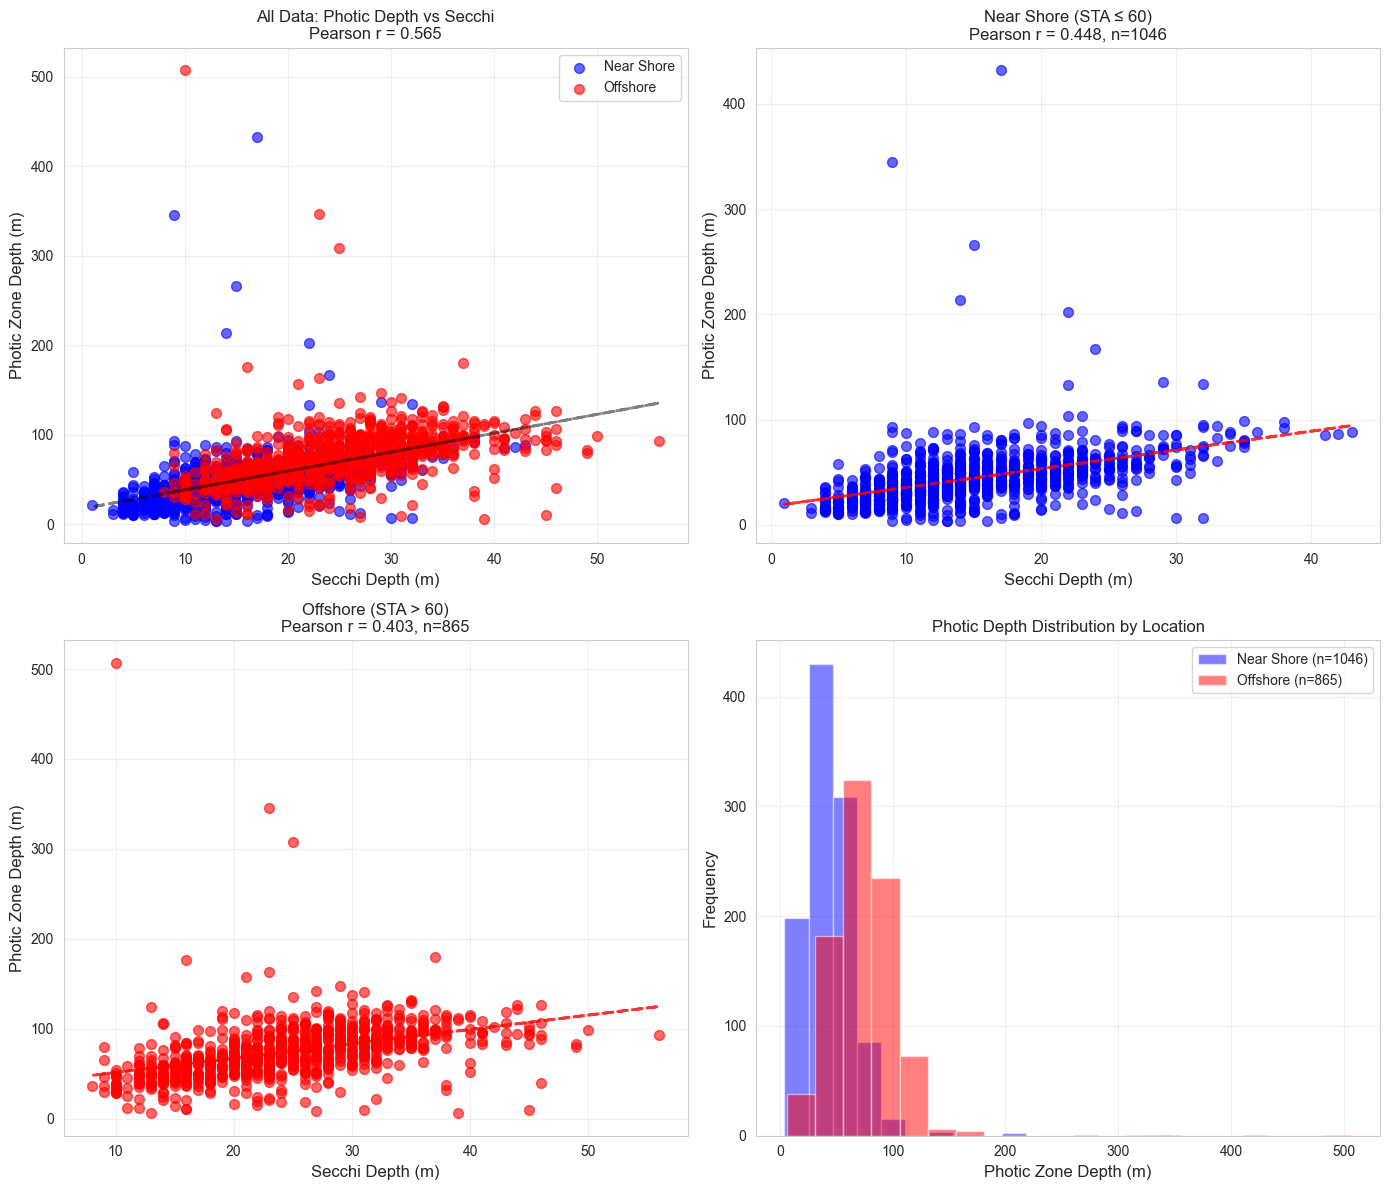

In [31]:
# ===== VISUALIZATIONS =====
print("\nCreating visualizations...")

# Set up the plotting style
sns.set_style("whitegrid")

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Overall scatter plot with color by shore proximity
if len(corr_df) > 0:
    for proximity, color in [('Near Shore', 'blue'), ('Offshore', 'red')]:
        subset = corr_df[corr_df['SHORE_PROXIMITY'] == proximity]
        if len(subset) > 0:
            axes[0, 0].scatter(subset['SECCHI'], subset['PHOTIC_DEPTH'], 
                             alpha=0.6, s=50, c=color, label=proximity)
    
    axes[0, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 0].set_title(f'All Data: Photic Depth vs Secchi\nPearson r = {pearson_overall[0]:.3f}', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add overall regression line
    z_all = np.polyfit(corr_df['SECCHI'], corr_df['PHOTIC_DEPTH'], 1)
    p_all = np.poly1d(z_all)
    axes[0, 0].plot(corr_df['SECCHI'], p_all(corr_df['SECCHI']), 
                   "k--", alpha=0.5, linewidth=2, label='Overall fit')

# Plot 2: Near Shore only
if len(near_shore_df) > 1:
    axes[0, 1].scatter(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='blue')
    axes[0, 1].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 1].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 1].set_title(f'Near Shore (STA ≤ 60)\nPearson r = {pearson_near[0]:.3f}, n={len(near_shore_df)}', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Add regression line
    z_near = np.polyfit(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 1)
    p_near = np.poly1d(z_near)
    axes[0, 1].plot(near_shore_df['SECCHI'], p_near(near_shore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 3: Offshore only
if len(offshore_df) > 1:
    axes[1, 0].scatter(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='red')
    axes[1, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[1, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[1, 0].set_title(f'Offshore (STA > 60)\nPearson r = {pearson_off[0]:.3f}, n={len(offshore_df)}', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add regression line
    z_off = np.polyfit(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 1)
    p_off = np.poly1d(z_off)
    axes[1, 0].plot(offshore_df['SECCHI'], p_off(offshore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 4: Distribution comparison
axes[1, 1].hist(near_shore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Near Shore (n={len(near_shore_df)})', color='blue')
axes[1, 1].hist(offshore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Offshore (n={len(offshore_df)})', color='red')
axes[1, 1].set_xlabel('Photic Zone Depth (m)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Photic Depth Distribution by Location', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

PLOT_PATH = Path("../results/1photic_depth_secchi_shore_comparison.png")
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
print(f"Visualization saved to {PLOT_PATH}")

# Making KD and Enhancing Data

In [92]:
# loading the new parquet
transformed_data = pd.read_parquet("../Data/Parquet/final_data.parquet")

print("Data loaded!")
print(f"Shape: {transformed_data.shape}")
print(f"Columns: {transformed_data.columns.tolist()}")

# ===== ADD SUMMED VALUES AND K_PAR =====
print("\n" + "="*60)
print("CALCULATING K_PAR AND SUMMED VALUES")
print("="*60)

# Initialize the new columns
transformed_data['XMISS_SUMMED'] = pd.NA
transformed_data['CHL_A_SUMMED'] = pd.NA
transformed_data['PHAEO_SUMMED'] = pd.NA
transformed_data['K_PAR'] = pd.NA

# Process each cast
cast_count = 0
for cast_id in transformed_data['CAST_COUNT'].unique():
    cast_count += 1
    
    # Get all rows for this cast
    cast_mask = transformed_data['CAST_COUNT'] == cast_id
    cast_data = transformed_data[cast_mask].copy()
    
    # Get the baseline depth for this cast
    baseline_depth_value = cast_data['baseline_depth'].iloc[0]
    
    # Skip if baseline_depth is NaN
    if pd.isna(baseline_depth_value):
        continue
    
    # Find the photic zone row
    photic_row = cast_data[cast_data['PHOTIC_ZONE'] == True]
    
    if len(photic_row) == 0:
        continue

    photic_depth = photic_row['DEPTH'].iloc[0]
    photic_idx = photic_row.index[0]
    par_at_photic = photic_row['PAR'].iloc[0]
    
    # Find PAR at baseline depth
    baseline_row = cast_data[cast_data['DEPTH'] == baseline_depth_value]
    
    if len(baseline_row) == 0 or pd.isna(par_at_photic):
        continue
    
    par_at_baseline = baseline_row['PAR'].iloc[0]

    # Calculate K_par: K_par = -log(PAR(z) / PAR(b)) / z_depth
    if not pd.isna(par_at_baseline) and par_at_baseline > 0 and par_at_photic > 0 and photic_depth > 0:
        k_par = -np.log(par_at_photic / par_at_baseline) / photic_depth
        transformed_data.loc[photic_idx, 'K_PAR'] = k_par
    
    # Get all rows between baseline depth and photic depth (inclusive)
    depth_range_mask = (
        cast_data['DEPTH'].notna() & 
        (cast_data['DEPTH'] >= baseline_depth_value) & 
        (cast_data['DEPTH'] <= photic_depth)
    )

    depth_range_data = cast_data[depth_range_mask]
    
    # Calculate sums (ignoring NaN values)
    xmiss_sum = depth_range_data['XMISS'].sum()
    chl_a_sum = depth_range_data['CHL_A'].sum()
    phaeo_sum = depth_range_data['PHAEO'].sum()
    
    # Assign to the photic zone row
    transformed_data.loc[photic_idx, 'XMISS_SUMMED'] = xmiss_sum if not pd.isna(xmiss_sum) else pd.NA
    transformed_data.loc[photic_idx, 'CHL_A_SUMMED'] = chl_a_sum if not pd.isna(chl_a_sum) else pd.NA
    transformed_data.loc[photic_idx, 'PHAEO_SUMMED'] = phaeo_sum if not pd.isna(phaeo_sum) else pd.NA
    
    # Print progress every 1000 casts
    if cast_count % 1000 == 0:
        print(f"Processed {cast_count} casts...")

print(f"\nProcessed {cast_count} total casts")
print("K_par calculation and summing complete!")

# ===== CREATE PHOTIC ZONE ONLY DATASET =====
print("\n" + "="*60)
print("CREATING PHOTIC ZONE ONLY DATASET")
print("="*60)

# Get only photic zone rows
photic_only_df = transformed_data[transformed_data['PHOTIC_ZONE'] == True].copy()

print(f"\nPhotic zone rows: {len(photic_only_df)}")

# For each photic zone row, make sure Secchi and other secchi columns are filled
for idx, row in photic_only_df.iterrows():
    cast_id = row['CAST_COUNT']

    # Find Secchi row for this cast (the row with Secchi data)
    cast_data = transformed_data[transformed_data['CAST_COUNT'] == cast_id]
    secchi_row = cast_data[cast_data['Secchi'].notna()]

    if len(secchi_row) > 0:
        # Copy Secchi and related columns from secchi row
        photic_only_df.loc[idx, 'Secchi'] = secchi_row['Secchi'].iloc[0]
        
        # Copy other Secchi dataset columns if they're NaN in photic row
        secchi_cols = ['Cruise_ID', 'Cruz_Sta', 'Distance', 'Date', 'Time', 
                      'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 
                      'IntChl', 'IntC14', 'TimeZone', 'Visibility']
        
        for col in secchi_cols:
            if col in secchi_row.columns and col in photic_only_df.columns:
                if pd.isna(photic_only_df.loc[idx, col]):
                    photic_only_df.loc[idx, col] = secchi_row[col].iloc[0]

# Select only the columns you specified (in order)
desired_columns = [
    'ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 
    'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 
    'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 
    'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Distance', 'Date', 'Time', 
    'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 
    'IntC14', 'TimeZone', 'Visibility', 'PHOTIC_ZONE', 'baseline_depth', 
    'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'K_PAR'
]

# Check which columns exist
existing_columns = [col for col in desired_columns if col in photic_only_df.columns]
missing_columns = [col for col in desired_columns if col not in photic_only_df.columns]

if missing_columns:
    print(f"\nWarning: These columns are missing: {missing_columns}")

# Create final dataset with only desired columns
photic_final_df = photic_only_df[existing_columns].copy()

# Save the photic zone only dataset
PHOTIC_ONLY_PATH = Path("../Data/Parquet/different_base_photic_zone_true_dataset.parquet")
photic_final_df.to_parquet(PHOTIC_ONLY_PATH, index=False)
print(f"\nPhotic zone only dataset saved to {PHOTIC_ONLY_PATH}")
print(f"Shape: {photic_final_df.shape}")

# Show summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\nTotal photic zone observations: {len(photic_final_df)}")
print(f"Observations with Secchi: {photic_final_df['Secchi'].notna().sum()}")
print(f"Observations with K_PAR: {photic_final_df['K_PAR'].notna().sum()}")
print(f"Observations with XMISS_SUMMED: {photic_final_df['XMISS_SUMMED'].notna().sum()}")
print(f"Observations with CHL_A_SUMMED: {photic_final_df['CHL_A_SUMMED'].notna().sum()}")
print(f"Observations with PHAEO_SUMMED: {photic_final_df['PHAEO_SUMMED'].notna().sum()}")


# Show sample of the dataset
print("\nSample of photic zone dataset (first 10 rows, key columns):")
sample_cols = ['CAST_COUNT', 'DEPTH', 'baseline_depth', 'PAR', 'K_PAR', 
               'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'Secchi']
available_sample_cols = [col for col in sample_cols if col in photic_final_df.columns]
print(photic_final_df[available_sample_cols].head(10))


# Check for any issues
print("\nData quality checks:")
if 'K_PAR' in photic_final_df.columns:
    # Convert K_PAR to numeric if it's not already
    if photic_final_df['K_PAR'].dtype == 'object' or photic_final_df['K_PAR'].dtype == 'string':
        photic_final_df['K_PAR'] = pd.to_numeric(photic_final_df['K_PAR'], errors='coerce')
    
    # Now check for issues
    k_par_numeric = pd.to_numeric(photic_final_df['K_PAR'], errors='coerce')
    print(f"Rows with negative K_PAR: {(k_par_numeric < 0).sum()}")
    print(f"Rows with infinite K_PAR: {np.isinf(k_par_numeric).sum()}")
    print(f"Rows with NaN K_PAR: {k_par_numeric.isna().sum()}")
    
    valid_kpar = k_par_numeric[k_par_numeric.notna() & ~np.isinf(k_par_numeric)]
    if len(valid_kpar) > 0:
        print(f"K_PAR range: {valid_kpar.min():.4f} to {valid_kpar.max():.4f}")



Data loaded!
Shape: (1255966, 38)
Columns: ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'PHOTIC_ZONE', 'baseline_depth']

CALCULATING K_PAR AND SUMMED VALUES
Processed 1000 casts...
Processed 2000 casts...

Processed 2774 total casts
K_par calculation and summing complete!

CREATING PHOTIC ZONE ONLY DATASET

Photic zone rows: 2388

Photic zone only dataset saved to ../Data/Parquet/different_base_photic_zone_true_dataset.parquet
Shape: (2388, 40)

SUMMARY

Total photic zone observations: 2388
Observations with Secchi: 2388
Observations with K_PAR: 2388
Observations with XMISS_SUMMED: 2388
Observations with CHL_A_SUMMED: 2388
Observation